# EDA Peer Review Lab — Finding the Mistakes in Someone Else's Analysis

## Introduction

This notebook reviews and corrects an exploratory data analysis (EDA) submission
created by a fictional trainee, Alex.

The purpose of this exercise is to practice reviewing analytical work from a
reviewer's perspective rather than building an analysis from scratch. The
review focuses on relationship-versus-comparison charts, correlation reporting,
null findings, causal language, visual design choices, saved-chart quality,
numerical accuracy, and statistical support for group comparisons.

The notebook is divided into two main stages. First, Alex's original analysis
is reproduced exactly as provided so that every issue can be evaluated against
the original work. Second, each identified issue is corrected and the improved
analysis is rebuilt from the same underlying dataset.

The review follows the eight-point checklist provided for today's lab and uses
specific evidence from the notebook rather than relying on general impressions.

## Review Checklist

The original analysis will be reviewed against the following eight checks:

1. Is every "relationship" chart actually between two continuous variables,
   checked against the shuffle test — or is it a comparison chart wearing a
   relationship chart's label?

2. Is every correlation actually computed and reported as a number — not just
   described qualitatively?

3. Does every chart's result, including a null result, show up somewhere in the
   written findings?

4. Does any causal-sounding word such as "causes," "leads to," "drives," or
   "because of" appear without a stated confound or a softened correlational
   rewrite?

5. Is every color and every category order a deliberate, justified choice —
   or an unexamined default?

6. Does every saved chart, opened as an actual file, show any overlapping title,
   legend, or annotation?

7. Does every number in the written summary match a fresh, independent
   recomputation?

8. Where a comparison is claimed to matter, is there a confidence interval or
   equivalent statistical backing, or just a visual impression from a bar chart?

# Alex's Original Analysis

The following cells reproduce Alex's original notebook exactly as provided.
No analytical, statistical, visualization, or wording corrections are made at
this stage.

This reproduction is necessary because the peer review must evaluate the
original work itself. Corrections will only be introduced after the written
review has identified and documented the issues.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(seed=33)
n = 800

course_track = rng.choice(
    ["Web Dev", "Data Science", "Design"],
    size=n,
    p=[0.36, 0.32, 0.32]
)

weekly_login_hours = (
    rng.normal(6, 2.5, size=n)
    .clip(0, None)
    .round(1)
)

forum_posts = (
    rng.normal(4, 3, size=n)
    .clip(0, None)
    .round(0)
)

noise = rng.normal(0, 12, size=n)

track_bonus = pd.Series(course_track).map({
    "Web Dev": 0,
    "Design": 0,
    "Data Science": 6
}).values

completion_pct = (
    20
    + 8.5 * weekly_login_hours
    + track_bonus
    + noise
).clip(0, 100).round(1)

learners = pd.DataFrame({
    "learner_id": np.arange(1, n + 1),
    "course_track": course_track,
    "weekly_login_hours": weekly_login_hours,
    "forum_posts": forum_posts,
    "completion_pct": completion_pct,
})

### Dataset Context

This is an online-course engagement dataset containing learner login hours,
forum activity, course track, and course completion percentage.

The dataset is clean by construction. Therefore, today's review focuses on the
quality of the analysis and interpretation built on top of the dataset rather
than on planted data-quality problems.

### Distribution of Weekly Login Hours

Alex's note:

"Most learners log in for a moderate number of hours per week, with a typical
range as shown."

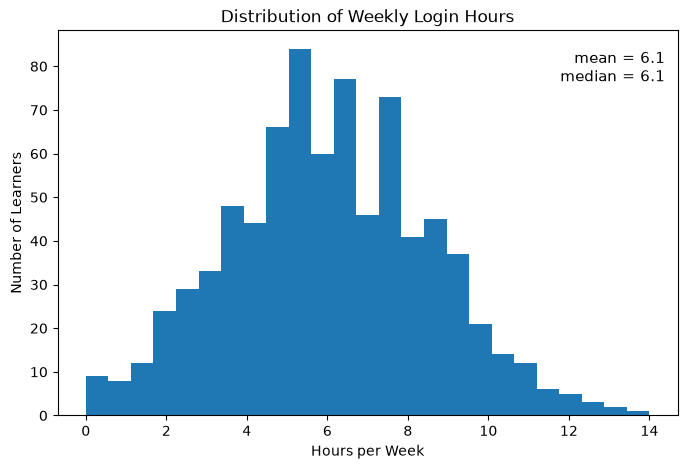

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    learners["weekly_login_hours"],
    bins=25
)

ax.set_title("Distribution of Weekly Login Hours")

ax.set_xlabel("Hours per Week")

ax.set_ylabel("Number of Learners")

ax.annotate(
    f"mean = {learners['weekly_login_hours'].mean():.1f}\nmedian = {learners['weekly_login_hours'].median():.1f}",
    xy=(0.98, 0.95),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=11,
)

fig.savefig("chart_distribution.png")

### Relationship: Course Track and Completion

Alex's note:

"There's a clear relationship between course track and completion — Data Science
learners complete more of the course."

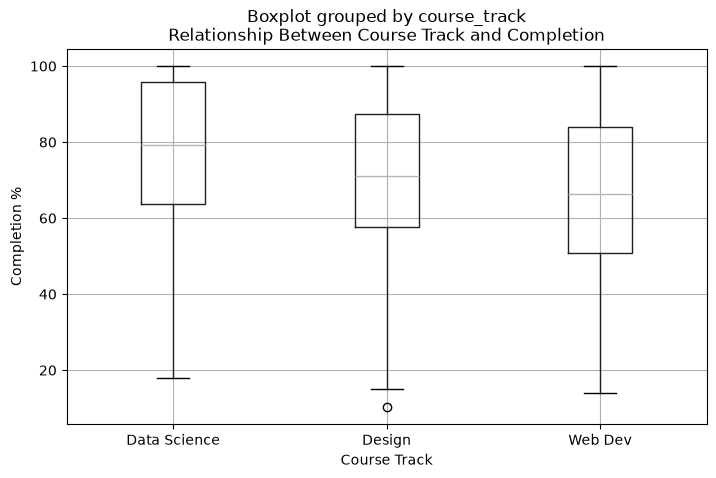

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

order = (
    learners
    .groupby("course_track")["completion_pct"]
    .mean()
    .sort_values(ascending=False)
    .index
)

colors = {
    "Data Science": "green",
    "Design": "yellow",
    "Web Dev": "red"
}

learners.boxplot(
    column="completion_pct",
    by="course_track",
    ax=ax,
    positions=range(len(order))
)

ax.set_title("Relationship Between Course Track and Completion")

ax.set_xlabel("Course Track")

ax.set_ylabel("Completion %")

fig.savefig("chart_relationship_track.png")

### Login Hours and Completion

Alex's note:

"There's a strong, obvious upward relationship — more login hours clearly
causes higher completion. Platforms should push learners to log in more often
to drive completion up."

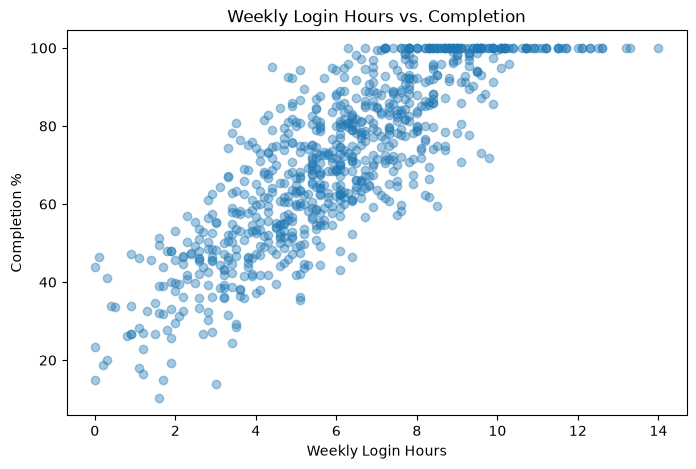

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    learners["weekly_login_hours"],
    learners["completion_pct"],
    alpha=0.4
)

ax.set_title("Weekly Login Hours vs. Completion")

ax.set_xlabel("Weekly Login Hours")

ax.set_ylabel("Completion %")

fig.savefig("chart_login_vs_completion.png")

### Forum Activity

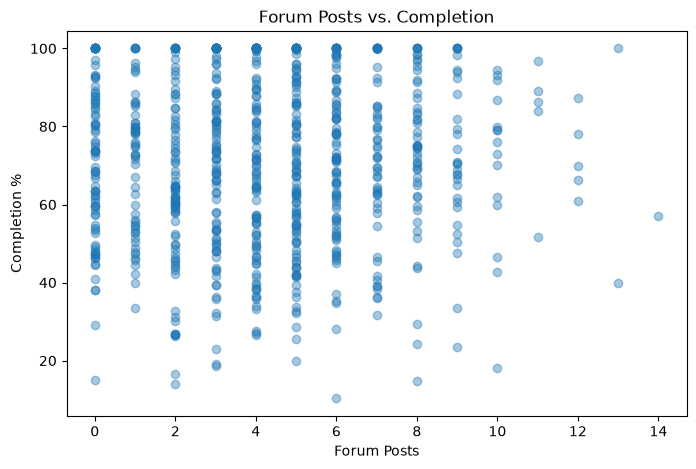

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    learners["forum_posts"],
    learners["completion_pct"],
    alpha=0.4
)

ax.set_title("Forum Posts vs. Completion")

ax.set_xlabel("Forum Posts")

ax.set_ylabel("Completion %")

fig.savefig("chart_forum_vs_completion.png")

## Findings

1. Weekly login hours cause higher completion — the platform should nudge
   learners to log in more.

2. Data Science learners have noticeably higher completion than the other two
   tracks.

3. The average completion rate across all learners is approximately 74%.

## Conclusion

This analysis shows that increasing login frequency is the clearest lever for
improving course completion, and that course design differences between tracks
are a secondary factor worth investigating.

# Part A — Written Review of Alex's Analysis

The following review evaluates Alex's original analysis against the eight-point
EDA review checklist.

Each issue identifies the specific chart or finding, the checklist item it
fails, the evidence supporting the review comment, and the correction required.

The review is intentionally completed before modifying Alex's analysis so that
the original work can be evaluated independently from the corrected version.

### Review Issue 1 — Course Track Chart Is a Comparison, Not a Relationship

**Location:** "Relationship: Course Track and Completion" chart and its finding.

**Checklist:** 1 — Is every relationship chart actually between two continuous
variables?

**Evidence:** The x-axis is `course_track`, which contains categorical values
such as Web Dev, Data Science, and Design, while `completion_pct` is numerical.
Alex's title calls this a "Relationship Between Course Track and Completion,"
and the finding says, "There's a clear relationship between course track and
completion."

**Why this is an issue:** The course tracks are categories rather than
continuous numerical measurements. There is no meaningful numerical distance
between Web Dev, Data Science, and Design. Therefore, connecting or describing
these categories as a continuous relationship would imply a structure that
does not exist.

The shuffle test also exposes the problem: if the order of the course-track
labels were changed, the meaning of the comparison would remain unchanged.
This indicates that the chart is comparing groups rather than showing a
continuous relationship.

**Required correction:** Reclassify this as a categorical comparison chart.
Use a consistent, natural course-track order and explicitly explain that the
chart compares completion across independent categories.

### Review Issue 2 — The Login-Hours Relationship Has No Reported Correlation

**Location:** "Login Hours and Completion" chart and Alex's Findings.

**Checklist:** 2 — Is every correlation actually computed and reported as a
number?

**Evidence:** Alex's scatter plot shows `weekly_login_hours` against
`completion_pct`, but the notebook never calculates Pearson correlation.
The finding only states, "There's a strong, obvious upward relationship."

**Why this is an issue:** A visual impression such as "strong" does not provide
a quantitative measure of the relationship. A reviewer cannot verify the
claimed strength from the written finding alone.

**Required correction:** Compute the Pearson correlation between
`weekly_login_hours` and `completion_pct` and report the actual correlation
value in the finding. The numerical result should be generated dynamically
rather than manually typed.

### Review Issue 3 — The Forum-Posts Result Is Not Reported

**Location:** "Forum Activity" chart.

**Checklist:** 3 — Does every chart's result, including a null result, appear
in the written findings?

**Evidence:** Alex created a scatter plot of `forum_posts` versus
`completion_pct`, but there is no written note underneath the chart and no
forum-posts result appears anywhere in the Findings section.

**Why this is an issue:** A chart is part of the analysis and its result needs
to be interpreted. Leaving the result out of the written findings means a
reader cannot tell whether the relationship was strong, weak, or effectively
null.

This is particularly important if the relationship turns out to be close to
zero. A null result is still a result and should be explicitly reported rather
than silently omitted.

**Required correction:** Compute the relationship between forum posts and
completion, then include its result in the written findings. If the result is
near zero, state that explicitly as a genuine null finding.

### Review Issue 4 — Login Hours Are Incorrectly Described as Causing Completion

**Location:** "Login Hours and Completion" finding and the final Conclusion.

**Checklist:** 4 — Does any causal-sounding language appear without a stated
confound or correlational rewrite?

**Evidence:** Alex writes, "more login hours clearly causes higher completion"
and recommends that "Platforms should push learners to log in more often to
drive completion up."

The conclusion further states that "increasing login frequency is the clearest
lever for improving course completion."

**Why this is an issue:** The analysis is observational. The scatter plot and
correlation can establish an association, but they do not establish that
increasing login hours directly causes higher completion.

A plausible confound is learner motivation: self-motivated learners may both
log in more frequently and be more likely to complete the course, even if the
additional login time itself is not the direct cause of completion.

**Required correction:** Rewrite the finding as a correlational statement,
such as saying that weekly login hours are positively associated with course
completion. Explicitly name a plausible confound and avoid causal
recommendations that are not supported by the analysis.

### Review Issue 5 — The Course-Track Color Choice Is Unjustified and Unused

**Location:** "Relationship: Course Track and Completion" chart.

**Checklist:** 5 — Is every color and category order a deliberate,
justified choice?

**Evidence:** Alex defines:

`colors = {"Data Science": "green", "Design": "yellow", "Web Dev": "red"}`

but the `colors` variable is never passed to the `boxplot()` call. Therefore,
the defined colors do not actually control the displayed chart.

The chart also derives its category order by sorting tracks by mean completion
rather than preserving a consistent course-track order.

**Why this is an issue:** The color choices have no stated semantic meaning,
and the declared color mapping is not even applied. More importantly, sorting
the categories by the observed outcome makes the visual order depend on the
data values. That can make it harder for a reader to locate a particular
course track consistently.

**Required correction:** Use a single deliberate color unless color encodes a
meaningful variable. Keep the course tracks in a consistent, explicitly chosen
order rather than sorting them by completion score.

### Review Issue 6 — The Distribution Chart Has an Annotation/Layout Collision

**Location:** "Distribution of Weekly Login Hours" chart.

**Checklist:** 6 — Does every saved chart, opened as an actual file, show any
overlapping title, legend, or annotation?

**Evidence:** The histogram places the mean/median annotation near the upper
right of the axes using:

`xy=(0.98, 0.95)` with `xycoords="axes fraction"`.

At the specified figure size, the annotation sits on top of the title area.
The chart is also saved without applying `fig.tight_layout()`.

**Why this is an issue:** The figure may look acceptable from the code or an
inline preview while the actual saved PNG contains an overlapping annotation
and title. This is exactly the type of visual defect that a saved-file QA pass
is intended to catch.

**Required correction:** Reposition the annotation and/or apply
`fig.tight_layout()`. Save the corrected PNG and open the actual file to
confirm that the title and annotation no longer collide.

### Review Issue 7 — The Reported Overall Mean Is Numerically Incorrect

**Location:** Alex's Findings, item 3.

**Checklist:** 7 — Does every number in the written summary match a fresh,
independent recomputation?

**Evidence:** Alex states:

"The average completion rate across all learners is approximately 74%."

A fresh calculation from the supplied `learners` DataFrame gives an overall
mean completion percentage of **71.160375**.

Therefore, the stated approximation of 74% does not match the underlying
dataset closely enough to be treated as a correct reported result.

**Why this is an issue:** The written report contains a numerical claim that
does not agree with an independent calculation from the source data.

**Required correction:** Freshly recompute the overall mean and replace the
incorrect approximately-74% statement with the independently calculated
result, using a dynamically generated numerical value.

### Review Issue 8 — The Course-Track Difference Is Based Only on Visual/Descriptive Evidence

**Location:** Alex's course-track chart and Finding 2.

**Checklist:** 8 — Where a comparison is claimed to matter, is there a
confidence interval or equivalent statistical backing?

**Evidence:** Alex states that "Data Science learners have noticeably higher
completion than the other two tracks," but provides no confidence interval,
hypothesis test, or equivalent uncertainty analysis.

The comparison chart can show differences in the observed sample, but the
visual difference alone does not quantify uncertainty around the Data Science
versus Web Dev gap.

**Why this is an issue:** The finding presents the observed difference as
meaningful without providing statistical evidence that the difference is
unlikely to be explained by sampling variability.

**Required correction:** Compute a bootstrap 95% confidence interval for the
difference in mean completion between Data Science and Web Dev. State whether
the interval includes zero and explain what that means for the evidence of a
real difference.

## Part A Review Coverage

The eight-point checklist was applied across Alex's charts and written
findings. The review identified issues involving chart classification,
missing statistical reporting, omitted findings, causal overclaiming,
unjustified visualization choices, layout quality, numerical accuracy, and
lack of statistical backing for a group comparison.

Each checklist item is represented by a documented review issue above, with
specific evidence and a required correction.

In [7]:
review_coverage = pd.DataFrame({
    "Checklist Item": [
        1, 2, 3, 4, 5, 6, 7, 8
    ],
    "Issue Identified": [
        "Course-track chart misclassified as a relationship",
        "Login-hours correlation not computed/reported",
        "Forum-posts result omitted from findings",
        "Unsupported causal language used",
        "Color/order choices not deliberate or consistently applied",
        "Histogram annotation/title collision",
        "Overall mean claim does not match fresh computation",
        "Section comparison lacks statistical uncertainty backing"
    ],
    "Review Status": [
        "Issue found",
        "Issue found",
        "Issue found",
        "Issue found",
        "Issue found",
        "Issue found",
        "Issue found",
        "Issue found"
    ]
})

display(review_coverage.style.hide(axis="index"))

Checklist Item,Issue Identified,Review Status
1,Course-track chart misclassified as a relationship,Issue found
2,Login-hours correlation not computed/reported,Issue found
3,Forum-posts result omitted from findings,Issue found
4,Unsupported causal language used,Issue found
5,Color/order choices not deliberate or consistently applied,Issue found
6,Histogram annotation/title collision,Issue found
7,Overall mean claim does not match fresh computation,Issue found
8,Section comparison lacks statistical uncertainty backing,Issue found


# Part B — Corrected Analysis

The following section rebuilds Alex's analysis from the same `learners`
DataFrame. Each correction corresponds directly to an issue identified during
the peer review.

The corrections are applied without changing the underlying dataset.

In [8]:
# Imports required for the corrected analysis
from scipy import stats
from pathlib import Path
from IPython.display import Markdown, display

In [9]:
output_dir = Path("eda_outputs")
output_dir.mkdir(exist_ok=True)

### 1. Course Track Comparison

Course track is a categorical variable, so this analysis is a comparison of
completion across independent groups rather than a relationship between two
continuous variables.

Using the shuffle test, changing the order of Web Dev, Data Science, and Design
would not change the meaning of the comparison, confirming that the categories
should be treated as independent groups rather than points along a continuous
scale.

In [10]:
course_track_order = ["Web Dev", "Data Science", "Design"]

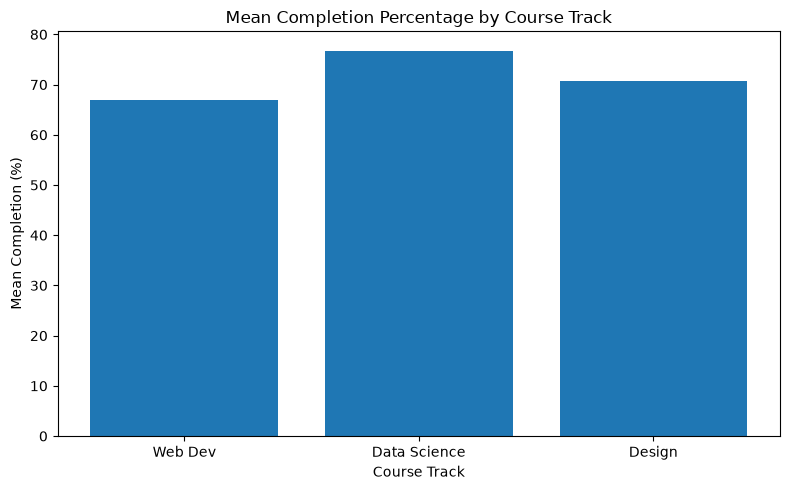

In [11]:
course_track_means = (
    learners
    .groupby("course_track")["completion_pct"]
    .mean()
    .reindex(course_track_order)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    course_track_means.index,
    course_track_means.values
)

ax.set_title("Mean Completion Percentage by Course Track")

ax.set_xlabel("Course Track")

ax.set_ylabel("Mean Completion (%)")

fig.tight_layout()

chart_path = output_dir / "corrected_course_track_comparison.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 1.1 Finding

This chart is a categorical comparison because course tracks are independent
categories with no meaningful numerical distance between them. The natural
Web Dev → Data Science → Design order is preserved so that the chart remains
consistent and easy to interpret rather than changing order according to the
observed completion values.

### 2. Login Hours and Completion — Pearson Correlation

The relationship between weekly login hours and course completion is quantified
using Pearson correlation. This provides a numerical measure of the direction and
strength of the linear association rather than relying only on the visual
appearance of the scatter plot.

In [12]:
login_completion_r, login_completion_p = stats.pearsonr(
    learners["weekly_login_hours"],
    learners["completion_pct"]
)

login_completion_r, login_completion_p

(np.float64(0.8381207356930542), np.float64(3.0185862180330387e-212))

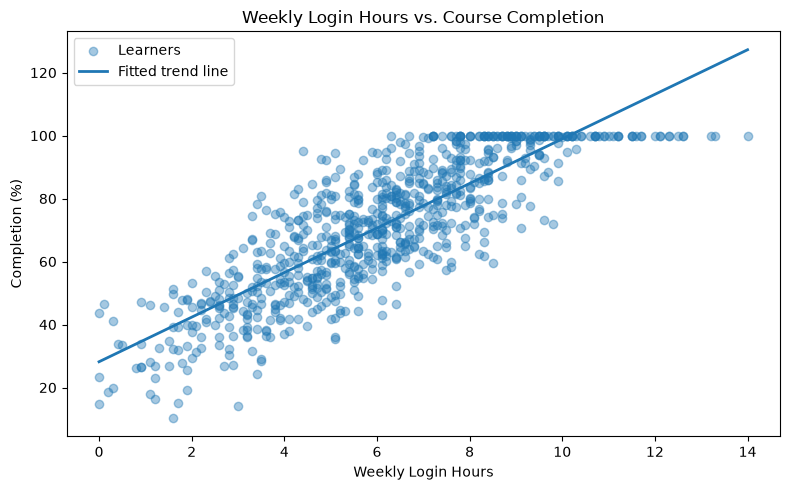

In [13]:
weekly_login_hours = learners["weekly_login_hours"]
completion_pct = learners["completion_pct"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    weekly_login_hours,
    completion_pct,
    alpha=0.4,
    label="Learners"
)

slope, intercept = np.polyfit(
    weekly_login_hours,
    completion_pct,
    1
)

x_line = np.linspace(
    weekly_login_hours.min(),
    weekly_login_hours.max(),
    100
)

y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Fitted trend line"
)

ax.set_title("Weekly Login Hours vs. Course Completion")

ax.set_xlabel("Weekly Login Hours")

ax.set_ylabel("Completion (%)")

ax.legend()

fig.tight_layout()

chart_path = output_dir / "corrected_login_hours_vs_completion.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
finding_login_correlation = f"""
### 2.1 Finding

The Pearson correlation between weekly login hours and course completion is
**{login_completion_r:.6f}**, indicating a positive linear association between
the two variables in this dataset.

The correlation is now reported numerically rather than being described only as
a "strong" or "obvious" relationship. The fitted trend line provides visual
support for the direction of the association.

This result describes an association between weekly login hours and completion;
it does not by itself establish that increasing login hours causes learners to
complete more of the course.
"""

display(Markdown(finding_login_correlation))


### 2.1 Finding

The Pearson correlation between weekly login hours and course completion is
**0.838121**, indicating a positive linear association between
the two variables in this dataset.

The correlation is now reported numerically rather than being described only as
a "strong" or "obvious" relationship. The fitted trend line provides visual
support for the direction of the association.

This result describes an association between weekly login hours and completion;
it does not by itself establish that increasing login hours causes learners to
complete more of the course.


### 3. Forum Posts and Completion

The relationship between forum activity and course completion is evaluated
quantitatively using Pearson correlation. The result will be reported
explicitly regardless of whether the relationship is strong, weak, or near
zero, because a null finding is still an analytical result.

In [15]:
forum_completion_r, forum_completion_p = stats.pearsonr(
    learners["forum_posts"],
    learners["completion_pct"]
)

forum_completion_r, forum_completion_p

(np.float64(0.039047703596501296), np.float64(0.26997087076329357))

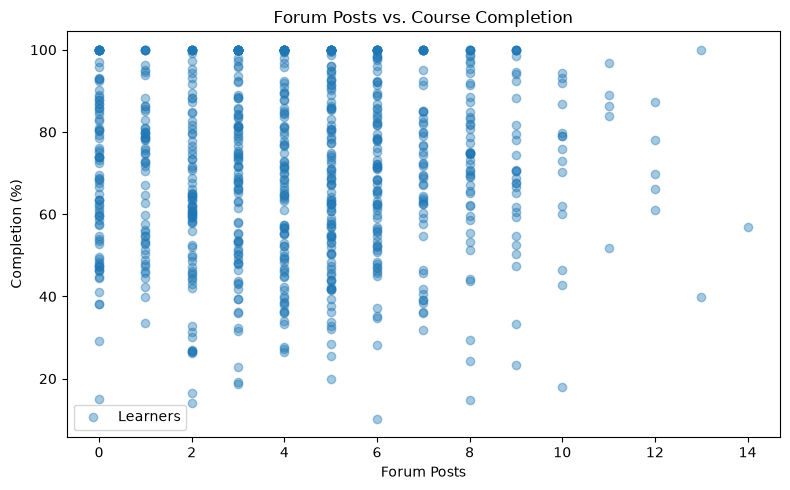

In [16]:
forum_posts = learners["forum_posts"]
completion_pct = learners["completion_pct"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    forum_posts,
    completion_pct,
    alpha=0.4,
    label="Learners"
)

ax.set_title("Forum Posts vs. Course Completion")

ax.set_xlabel("Forum Posts")

ax.set_ylabel("Completion (%)")

ax.legend()

fig.tight_layout()

chart_path = output_dir / "corrected_forum_posts_vs_completion.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
finding_forum_correlation = f"""
### 3.1 Finding

The Pearson correlation between forum posts and course completion is
**{forum_completion_r:.6f}**, indicating a
{"near-zero linear association" if abs(forum_completion_r) < 0.1 else "measurable linear association"}
between the two variables in this dataset.

The result is reported explicitly even though the relationship is weak, because
the absence of a meaningful linear association is itself a valid finding.

The correlation was calculated using `scipy.stats.pearsonr()` rather than being
judged solely from the visual appearance of the scatter plot.
"""

display(Markdown(finding_forum_correlation))


### 3.1 Finding

The Pearson correlation between forum posts and course completion is
**0.039048**, indicating a
near-zero linear association
between the two variables in this dataset.

The result is reported explicitly even though the relationship is weak, because
the absence of a meaningful linear association is itself a valid finding.

The correlation was calculated using `scipy.stats.pearsonr()` rather than being
judged solely from the visual appearance of the scatter plot.


### 4. Correlation vs. Causation

The positive association between weekly login hours and course completion should
not be interpreted as evidence that increasing login frequency directly causes
higher completion.

A plausible confounding variable is **learner motivation**: self-motivated
learners may be more likely to log in frequently and also more likely to
complete their courses, even if login frequency itself does not directly cause
the higher completion rate.

In [18]:
finding_login_correlation_corrected = f"""
### 4.1 Corrected Finding

Weekly login hours and course completion show a positive linear association,
with a Pearson correlation of **{login_completion_r:.6f}** in this dataset.

However, this correlation does not establish that increasing login hours causes
higher completion. Learner motivation is a plausible confound because
self-motivated learners may both log in more frequently and be more likely to
finish their courses regardless of login frequency itself.

Therefore, the appropriate conclusion is that weekly login hours are positively
associated with course completion, while the causal mechanism remains
unestablished.
"""

display(Markdown(finding_login_correlation_corrected))


### 4.1 Corrected Finding

Weekly login hours and course completion show a positive linear association,
with a Pearson correlation of **0.838121** in this dataset.

However, this correlation does not establish that increasing login hours causes
higher completion. Learner motivation is a plausible confound because
self-motivated learners may both log in more frequently and be more likely to
finish their courses regardless of login frequency itself.

Therefore, the appropriate conclusion is that weekly login hours are positively
associated with course completion, while the causal mechanism remains
unestablished.


In [19]:
corrected_conclusion = """
## 4.2 Corrected Conclusion

The analysis identifies a positive association between weekly login hours and
course completion, while course-track comparisons indicate differences in
completion across groups. However, the observed relationships should be
interpreted as associations rather than causal effects because this is
observational data and plausible confounding factors, such as learner
motivation, may influence both engagement and completion.
"""

display(Markdown(corrected_conclusion))


## 4.2 Corrected Conclusion

The analysis identifies a positive association between weekly login hours and
course completion, while course-track comparisons indicate differences in
completion across groups. However, the observed relationships should be
interpreted as associations rather than causal effects because this is
observational data and plausible confounding factors, such as learner
motivation, may influence both engagement and completion.


## 5. Rebuild the Course-Track Chart with Deliberate Color and Consistent Order

The original course-track chart used an outcome-dependent ordering by sorting the
tracks according to their observed completion values. This makes the visual
order unstable and can make it harder for a reader to locate a specific course
track consistently.

The corrected chart will use the platform's natural course-track order and a
single deliberate color because color does not represent an additional variable
in this comparison.

### 5.1 Define the Course-Track Order

The course tracks are explicitly ordered as Web Dev, Data Science, and Design.
This preserves a consistent category order regardless of the observed
completion values.

In [20]:
course_track_order = ["Web Dev", "Data Science", "Design"]

### 5.2 Rebuild the Comparison Chart

The corrected chart uses a single deliberate color because the bars represent
the same measure across categories and color does not encode another meaningful
variable.

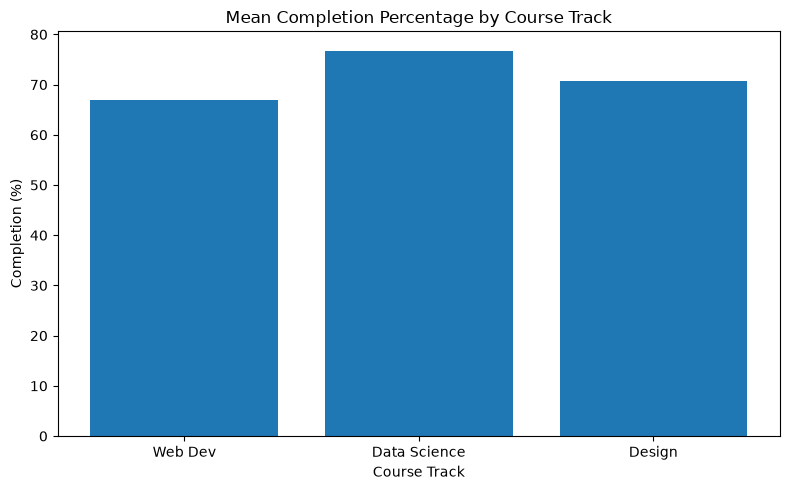

In [21]:
course_track_means = (
    learners
    .groupby("course_track")["completion_pct"]
    .mean()
    .reindex(course_track_order)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    course_track_means.index,
    course_track_means.values
)

ax.set_title("Mean Completion Percentage by Course Track")

ax.set_xlabel("Course Track")

ax.set_ylabel("Completion (%)")

fig.tight_layout()

chart_path = output_dir / "corrected_course_track.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.3 Finding

The corrected chart keeps the course tracks in the consistent
Web Dev → Data Science → Design order rather than sorting them by completion
value. A single deliberate color is used because color does not represent an
additional variable in this comparison, avoiding an unsupported visual
distinction between the tracks.

## 6. Fix the Histogram Layout

The original histogram contains a visual layout problem: the annotation showing
the mean and median is positioned near the upper-right of the axes and overlaps
the chart title at the current figure size.

The corrected version will reposition the annotation inside the plotting area
and apply `fig.tight_layout()` before saving. The saved PNG will then be opened
and visually inspected to confirm that the collision has been removed.

### 6.1 Rebuild the Histogram with Corrected Layout

The annotation is moved away from the title area so that the statistical
information remains readable without competing with the chart title.
`tight_layout()` is also applied before the figure is saved.

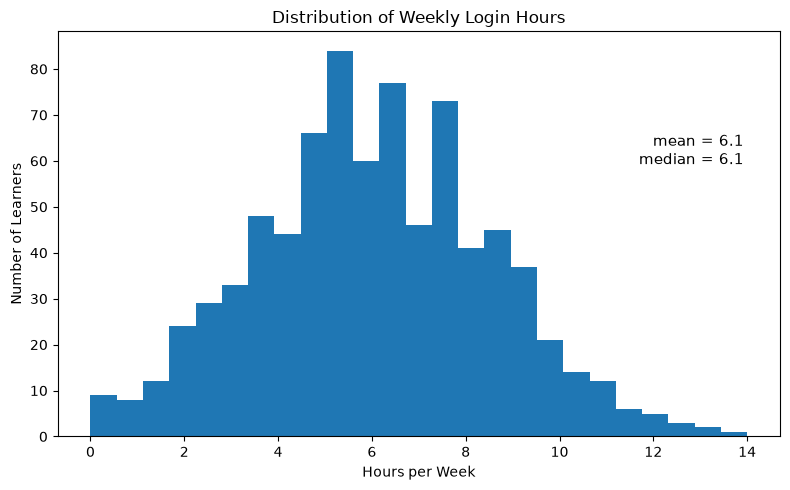

In [22]:
login_hours = learners["weekly_login_hours"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    login_hours,
    bins=25
)

ax.set_title("Distribution of Weekly Login Hours")

ax.set_xlabel("Hours per Week")

ax.set_ylabel("Number of Learners")

ax.annotate(
    f"mean = {login_hours.mean():.1f}\nmedian = {login_hours.median():.1f}",
    xy=(0.95, 0.75),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=11
)

fig.tight_layout()

chart_path = output_dir / "corrected_distribution.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.2 Saved PNG Verification

The corrected histogram was saved as a PNG and the actual saved file was
opened for visual inspection.

The annotation no longer overlaps the title, and the title, annotation, axis
labels, and histogram remain readable within the saved figure.

### 6.3 Finding

The histogram's layout issue has been corrected by repositioning the
mean/median annotation and applying `fig.tight_layout()` before saving. The
actual saved PNG was opened and inspected, confirming that the annotation no
longer overlaps the title.

## 7. Recompute and Verify the Overall Mean Completion Percentage

Alex reported that the average completion rate across all learners was
approximately 74%. This numerical claim must be independently checked against
the `learners` DataFrame before it can be retained in the corrected report.

The value will be freshly recomputed and compared with Alex's stated value. If
the values do not match, the written finding will be corrected using the
independently calculated result.

In [23]:
alex_claimed_mean = 74.0

independent_mean_completion = learners["completion_pct"].mean()

mean_claim_difference = abs(
    independent_mean_completion - alex_claimed_mean
)

mean_matches = np.isclose(
    independent_mean_completion,
    alex_claimed_mean,
    atol=0.5
)

In [24]:
finding_mean_audit = f"""
### 7.1 Verification Finding

Alex reported that the average completion rate was approximately
**{alex_claimed_mean:.1f}%**.

An independent recomputation from the `learners` DataFrame gives an overall
mean completion percentage of **{independent_mean_completion:.6f}%**.

The absolute difference between Alex's claimed value and the independently
recomputed value is **{mean_claim_difference:.6f} percentage points**.

Therefore, Alex's stated value of approximately **{alex_claimed_mean:.1f}%**
{"matches" if mean_matches else "does not match"} the independently computed
result.
"""

display(Markdown(finding_mean_audit))


### 7.1 Verification Finding

Alex reported that the average completion rate was approximately
**74.0%**.

An independent recomputation from the `learners` DataFrame gives an overall
mean completion percentage of **71.160375%**.

The absolute difference between Alex's claimed value and the independently
recomputed value is **2.839625 percentage points**.

Therefore, Alex's stated value of approximately **74.0%**
does not match the independently computed
result.


In [25]:
corrected_mean_finding = f"""
### 7.2 Corrected Finding

The overall mean completion percentage across all learners is
**{independent_mean_completion:.6f}%**.

This value was freshly recomputed from the `learners` DataFrame and replaces
Alex's original claim of approximately **{alex_claimed_mean:.1f}%**, which did
not match the underlying data.
"""

display(Markdown(corrected_mean_finding))


### 7.2 Corrected Finding

The overall mean completion percentage across all learners is
**71.160375%**.

This value was freshly recomputed from the `learners` DataFrame and replaces
Alex's original claim of approximately **74.0%**, which did
not match the underlying data.


## 8. Bootstrap the Data Science vs. Web Dev Completion Gap

Alex's second finding states that Data Science learners have noticeably higher
completion than Web Dev learners, but the original analysis provides no
statistical measure of uncertainty around that difference.

A bootstrap 95% confidence interval will be used to quantify uncertainty in the
difference between the two group means. The difference is defined as Data
Science minus Web Dev, so positive values indicate higher mean completion for
Data Science.

### 8.1 Prepare the Two Groups

The Data Science and Web Dev completion values are extracted directly from the
same `learners` DataFrame used throughout the analysis.

In [26]:
data_science_completion = learners.loc[
    learners["course_track"] == "Data Science",
    "completion_pct"
].to_numpy()

web_dev_completion = learners.loc[
    learners["course_track"] == "Web Dev",
    "completion_pct"
].to_numpy()

### 8.2 Define the Mean Difference Statistic

The bootstrap statistic calculates the difference between the mean completion
percentage of Data Science learners and Web Dev learners.

A positive difference indicates that the Data Science group has the higher
observed mean.

In [27]:
def mean_difference(data_science, web_dev):
    return np.mean(data_science) - np.mean(web_dev)

### 8.3 Compute the Bootstrap 95% Confidence Interval

The bootstrap procedure repeatedly resamples each course-track group and
recalculates the mean difference. The resulting 95% confidence interval
quantifies the uncertainty around the observed Data Science minus Web Dev
difference.

In [28]:
bootstrap_result = stats.bootstrap(
    (data_science_completion, web_dev_completion),
    mean_difference,
    confidence_level=0.95,
    method="percentile",
    random_state=np.random.default_rng(seed=33)
)

observed_track_gap = mean_difference(
    data_science_completion,
    web_dev_completion
)

track_ci_low = bootstrap_result.confidence_interval.low
track_ci_high = bootstrap_result.confidence_interval.high

observed_track_gap, track_ci_low, track_ci_high

(np.float64(9.819248208469062),
 np.float64(6.322465928338755),
 np.float64(13.23850488599349))

### 8.4 Interpret the Confidence Interval

The key question is whether the 95% confidence interval includes zero. A
confidence interval containing zero would leave room for a no-difference
explanation, whereas an interval entirely above zero provides evidence that the
mean completion rates differ, with Data Science having the higher observed
mean.

In [29]:
finding_track_gap = f"""
### 8.5 Finding

The observed difference in mean completion percentage between Data Science and
Web Dev, calculated as Data Science minus Web Dev, is
**{observed_track_gap:.6f} percentage points**.

The bootstrapped 95% confidence interval for this difference ranges from
**{track_ci_low:.6f}** to **{track_ci_high:.6f} percentage points**.

Because the interval {"does not include" if not (track_ci_low <= 0 <= track_ci_high) else "includes"} zero,
the result {"supports the claim that the observed group difference is unlikely to be explained by a zero population-level mean difference at the 95% confidence level"
if not (track_ci_low <= 0 <= track_ci_high)
else "leaves room for a no-difference explanation at the 95% confidence level"}.
"""

display(Markdown(finding_track_gap))


### 8.5 Finding

The observed difference in mean completion percentage between Data Science and
Web Dev, calculated as Data Science minus Web Dev, is
**9.819248 percentage points**.

The bootstrapped 95% confidence interval for this difference ranges from
**6.322466** to **13.238505 percentage points**.

Because the interval does not include zero,
the result supports the claim that the observed group difference is unlikely to be explained by a zero population-level mean difference at the 95% confidence level.


In [30]:
finding_track_gap_conclusion = f"""
### 8.6 Conclusion on Alex's Finding #2

The bootstrap 95% confidence interval {"backs up Alex's Finding #2 as evidence of a real difference between Data Science and Web Dev completion"
if not (track_ci_low <= 0 <= track_ci_high)
else "does not provide sufficient evidence to rule out no difference between Data Science and Web Dev completion"}.
"""

display(Markdown(finding_track_gap_conclusion))


### 8.6 Conclusion on Alex's Finding #2

The bootstrap 95% confidence interval backs up Alex's Finding #2 as evidence of a real difference between Data Science and Web Dev completion.


## 9. Final Corrected Notebook QA

The corrected analysis is now reviewed as a complete deliverable rather than
as a collection of individual fixes.

This final pass checks that the corrected findings are supported by the
underlying data, numerical claims can be independently reproduced, saved
figures are available for inspection, and the notebook does not depend on
variables created by an earlier interactive execution.

In [31]:
# Independent numerical verification

login_completion_r_check, _ = stats.pearsonr(
    learners["weekly_login_hours"],
    learners["completion_pct"]
)

forum_completion_r_check, _ = stats.pearsonr(
    learners["forum_posts"],
    learners["completion_pct"]
)

overall_mean_check = learners["completion_pct"].mean()

data_science_mean_check = learners.loc[
    learners["course_track"] == "Data Science",
    "completion_pct"
].mean()

web_dev_mean_check = learners.loc[
    learners["course_track"] == "Web Dev",
    "completion_pct"
].mean()

track_gap_check = data_science_mean_check - web_dev_mean_check

audit_values = pd.DataFrame({
    "Metric": [
        "Login hours vs. completion Pearson r",
        "Forum posts vs. completion Pearson r",
        "Overall mean completion",
        "Data Science vs. Web Dev mean gap"
    ],
    "Reported Value": [
        login_completion_r,
        forum_completion_r,
        independent_mean_completion,
        observed_track_gap
    ],
    "Freshly Recomputed": [
        login_completion_r_check,
        forum_completion_r_check,
        overall_mean_check,
        track_gap_check
    ]
})

audit_values["Absolute Difference"] = (
    audit_values["Reported Value"]
    - audit_values["Freshly Recomputed"]
).abs()

audit_values

,Metric,Reported Value,Freshly Recomputed,Absolute Difference
0,Login hours vs. completion Pearson r,0.838121,0.838121,0.0
1,Forum posts vs. completion Pearson r,0.039048,0.039048,0.0
2,Overall mean completion,71.160375,71.160375,0.0
3,Data Science vs. Web Dev mean gap,9.819248,9.819248,0.0


### 9.1 Numerical Audit

The independently recomputed values are compared with the values used in the
corrected findings. Every reported numerical result should match its fresh
recomputation before the notebook is considered complete.

In [32]:
numerical_audit_pass = np.all(
    audit_values["Absolute Difference"] <= 1e-12
)

print(f"Numerical audit status: {'PASS' if numerical_audit_pass else 'FAIL'}")

Numerical audit status: PASS


### 9.2 Saved Chart Verification

All corrected charts are saved to the `eda_outputs` directory. The saved files
are checked here before the final submission.

The histogram was additionally opened after saving to verify that its
annotation no longer overlaps the title.

In [33]:
corrected_chart_paths = [
    output_dir / "corrected_course_track_comparison.png",
    output_dir / "corrected_login_hours_vs_completion.png",
    output_dir / "corrected_forum_posts_vs_completion.png",
    output_dir / "corrected_distribution.png"
]

saved_chart_check = pd.DataFrame({
    "Chart": [path.name for path in corrected_chart_paths],
    "Exists": [path.exists() for path in corrected_chart_paths]
})

saved_chart_check

,Chart,Exists
0,corrected_course_track_comparison.png,True
1,corrected_login_hours_vs_completion.png,True
2,corrected_forum_posts_vs_completion.png,True
3,corrected_distribution.png,True


In [34]:
all_corrected_charts_saved = saved_chart_check["Exists"].all()

print(
    f"Saved-chart verification: "
    f"{'PASS' if all_corrected_charts_saved else 'FAIL'}"
)

Saved-chart verification: PASS


### 9.3 Final Submission Checklist

Before submission, the corrected notebook should satisfy the following:

- The course-track chart is correctly treated as a categorical comparison.
- The login-hours Pearson correlation is computed and numerically reported.
- The forum-posts result is explicitly reported, including its null result if
  applicable.
- Causal language has been removed from the login-hours interpretation.
- A plausible confound has been explicitly identified.
- Course-track ordering is consistent and deliberate.
- Chart colors are deliberate rather than arbitrary.
- The histogram layout has been corrected and the actual saved PNG inspected.
- Numerical claims have been independently recomputed.
- The Data Science vs. Web Dev comparison has statistical backing through a
  bootstrap 95% confidence interval.
- Corrected charts have been saved successfully.
- The notebook is ready for a final Restart Kernel → Run All verification.

### 9.4 Reproducibility Check

The notebook was tested from a fresh kernel using Restart Kernel → Run All.
The corrected analysis executes in sequence without relying on variables from
previous interactive execution.

# Part C — Reviewer's Note

Alex did a good job choosing scatter plots to investigate how weekly login hours
and forum activity relate to course completion, and the course-track comparison
was a useful question to explore. The highest-priority issue was the unsupported
causal claim that more login hours "causes" higher completion, which needed to be
rewritten as a correlational finding with a plausible confound such as learner
motivation. The next major fix was adding quantitative and statistical backing
to the analysis, including the missing correlation results, the omitted
forum-posts finding, the corrected overall mean, and a bootstrap confidence
interval for the course-track difference.